In [3]:
from pathlib import Path
import pandas as pd

# Use repo-relative `pr` directory (Windows)
print("cwd:", Path.cwd())
base_path = Path("pr")
print("resolved:", base_path.resolve())
print("exists:", base_path.exists())

records = []
if base_path.exists():
    for f in sorted(base_path.rglob("*")):
        if not f.is_file():
            continue

        read_ok = True
        detail = "ok"
        n_rows = None
        n_cols = None

        try:
            ext = f.suffix.lower()

            if ext == ".csv":
                df_tmp = pd.read_csv(f)
                n_rows, n_cols = df_tmp.shape
            elif ext in [".tsv", ".txt"]:
                df_tmp = pd.read_csv(f, sep="\t")
                n_rows, n_cols = df_tmp.shape
            elif ext == ".json":
                df_tmp = pd.read_json(f)
                n_rows, n_cols = df_tmp.shape
            elif ext == ".parquet":
                df_tmp = pd.read_parquet(f)
                n_rows, n_cols = df_tmp.shape
            elif ext in [".xlsx", ".xls"]:
                df_tmp = pd.read_excel(f)
                n_rows, n_cols = df_tmp.shape
            else:
                # Validación básica de lectura para otros tipos
                with open(f, "rb") as fh:
                    _ = fh.read(1024)

        except Exception as e:
            read_ok = False
            detail = str(e)

        records.append(
            {
                "file_name": f.name,
                "file_path": str(f),
                "size_bytes": f.stat().st_size,
                "read_ok": read_ok,
                "rows": n_rows,
                "cols": n_cols,
                "detail": detail,
            }
        )
else:
    print(f"No existe la ruta: {base_path}")

df_files = pd.DataFrame(records)

cwd: c:\Users\elxpa\Documents\GitHub\TESIS
resolved: C:\Users\elxpa\Documents\GitHub\TESIS\pr
exists: True


In [4]:
# Cargar dataset CR2MET desde los archivos en `pr` y definir punto de Stgo centro
import xarray as xr
from pathlib import Path

pr_dir = Path('pr')
files = sorted(pr_dir.glob('CR2MET_pr_v2.5_day_*.nc'))
print('Archivos encontrados:', len(files))
if not files:
    raise RuntimeError('No se encontraron archivos CR2MET en pr/')

# Abrir con xarray (usar dask para eficiencia si está disponible)
ds = xr.open_mfdataset([str(p) for p in files], combine='by_coords', parallel=True, chunks={'time': 365})

# Coordenadas de Santiago centro
lat_sc = -33.45
lon_sc = -70.66

pr_sc = ds["pr"].sel(lat=lat_sc, lon=lon_sc, method="nearest")

# Intentar seleccionar el punto más cercano usando nombres de coordenadas comunes
lat_name = next((n for n in ds.coords if 'lat' in n.lower()), None)
lon_name = next((n for n in ds.coords if 'lon' in n.lower()), None)


Archivos encontrados: 672


C:\Users\elxpa\AppData\Local\Temp\ipykernel_10764\4249810639.py:12: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset([str(p) for p in files], combine='by_coords', parallel=True, chunks={'time': 365})


In [5]:
pr_sc = pr_sc.sel(time=slice("1979-01-01", "2021-12-31"))
dry_day = (pr_sc < 1.0)

In [6]:
import numpy as np
import pandas as pd

def dry_spells_from_bool(time_index, dry_bool, min_len=1):
    dry = np.asarray(dry_bool, dtype=bool)

    x = np.r_[False, dry, False]
    dx = np.diff(x.astype(int))

    starts = np.where(dx == 1)[0]
    ends_excl = np.where(dx == -1)[0]
    lengths = ends_excl - starts

    mask = lengths >= min_len
    starts = starts[mask]
    ends_excl = ends_excl[mask]
    lengths = lengths[mask]

    t = np.asarray(time_index)
    start_dates = t[starts]
    end_dates = t[ends_excl - 1]

    df = pd.DataFrame({
        "start": pd.to_datetime(start_dates),
        "end": pd.to_datetime(end_dates),
        "duration_days": lengths.astype(int)
    }).sort_values("start").reset_index(drop=True)

    return df

df_spells = dry_spells_from_bool(
    time_index=pr_sc["time"].values,
    dry_bool=dry_day.values,
    min_len=1
)



<>:69: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:69: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\elxpa\AppData\Local\Temp\ipykernel_10764\1830090918.py:69: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  tL_str = f"{tL:.1f}d" if tL != np.inf else "$\infty$"


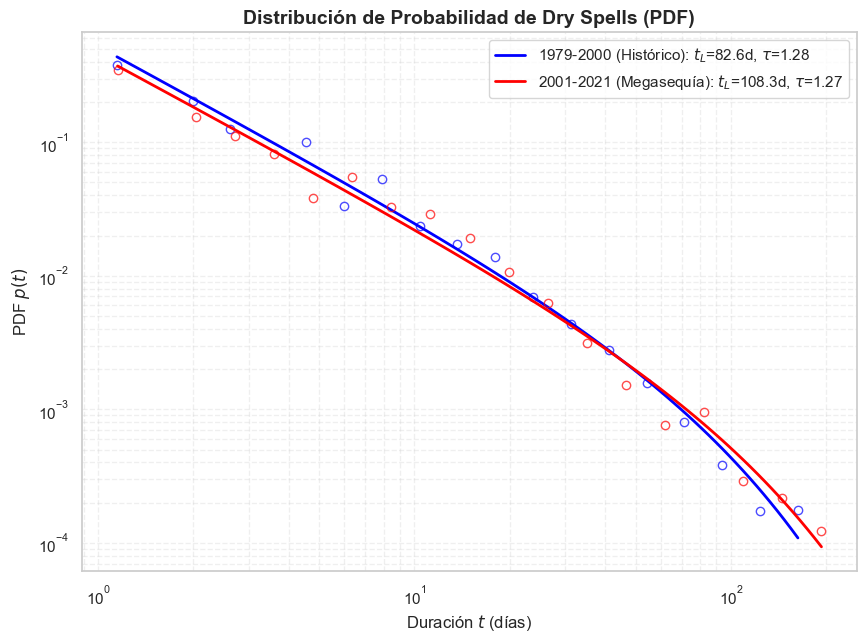

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. REHACER LA EXTRACCIÓN SIN MÍNIMO DE DURACIÓN (min_len=1)
# Asumiendo que pr_sc y dry_day ya están definidos en tu notebook
df_spells_all = dry_spells_from_bool(
    time_index=pr_sc["time"].values,
    dry_bool=dry_day.values,
    min_len=1  # <--- CRÍTICO: El profe pidió no usar un mínimo
)

# Preparar columnas
df = df_spells_all.copy()
df["year"] = pd.to_datetime(df["start"]).dt.year

# 2. SEPARAR LOS PERIODOS
df_p1 = df[df["year"] <= 2000]["duration_days"].values
df_p2 = df[df["year"] > 2000]["duration_days"].values

periodos = [
    {"data": df_p1, "label": "1979-2000 (Histórico)", "color": "blue"},
    {"data": df_p2, "label": "2001-2021 (Megasequía)", "color": "red"}
]

# Configurar el gráfico
plt.figure(figsize=(10, 7))

for p in periodos:
    data = p["data"]
    data = data[data > 0] # Asegurar que no hay ceros
    
    # 3. BINNING LOGARÍTMICO
    bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 20)
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:]) # Centro geométrico
    
    # Filtrar bins vacíos para poder aplicar logaritmo (ln(0) da error)
    valid_bins = counts > 0
    x_val = bin_centers[valid_bins]
    y_val = counts[valid_bins]
    
    # 4. FIT MEDIANTE REGRESIÓN LINEAL MÚLTIPLE (Apéndice A del Paper)
    # Ecuación: ln(p) = c1 + c2*ln(x) + c3*x
    Y = np.log(y_val)
    X_matrix = np.column_stack((np.ones(len(x_val)), np.log(x_val), x_val))
    
    # Resolvemos el sistema de mínimos cuadrados para hallar los coeficientes
    c, residuals, rank, s = np.linalg.lstsq(X_matrix, Y, rcond=None)
    c1, c2, c3 = c
    
    # Recuperamos los parámetros físicos
    tau = -c2
    
    # Si c3 es positivo, no hay decaimiento exponencial (el cutoff tiende a infinito)
    # Físicamente debería ser negativo. Lo calculamos:
    tL = -1.0 / c3 if c3 < 0 else np.inf 
    A_fit = np.exp(c1)
    
    # 5. GENERAR CURVA DEL FIT PARA GRAFICAR
    t_range = np.logspace(np.log10(min(x_val)), np.log10(max(x_val)), 100)
    fit_curve = A_fit * (t_range**(-tau)) * np.exp(-t_range/tL)
    
    # Graficar puntos reales y línea de ajuste
    plt.loglog(x_val, y_val, 'o', color=p["color"], mfc='none', alpha=0.7)
    
    # Añadir al plot con el label como pidió el profesor
    # Usamos formato condicional para tL en caso de que tienda a infinito
    tL_str = f"{tL:.1f}d" if tL != np.inf else "$\infty$"
    plt.plot(t_range, fit_curve, color=p["color"], lw=2,
             label=f"{p['label']}: $t_L$={tL_str}, $\\tau$={tau:.2f}")

# Estética del gráfico
plt.title("Distribución de Probabilidad de Dry Spells (PDF)", fontsize=14, fontweight='bold')
plt.xlabel("Duración $t$ (días)")
plt.ylabel("PDF $p(t)$")
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

## Realizar Análisis de significancia estadística

El test K-S no asume ninguna distribución teórica previa (es no paramétrico). Lo que hace es calcular la Función de Distribución Acumulada Empírica (ECDF) para ambos periodos y busca el punto donde la distancia vertical entre ambas curvas es la máxima.  Si esa distancia máxima es demasiado grande para ser producto del azar, rechaza la Hipótesis Nula.

In [8]:
from scipy import stats

# Realizar el test K-S de dos muestras
ks_stat, p_value = stats.ks_2samp(df_p1, df_p2)

print("=== Test de Kolmogorov-Smirnov ===")
print(f"Estadístico K-S (Distancia máxima): {ks_stat:.4f}")
print(f"Valor p: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusión: Las distribuciones de los periodos SON estadísticamente diferentes (Rechazamos H0).")
else:
    print("Conclusión: NO hay evidencia suficiente para decir que las distribuciones son diferentes (Mantenemos H0).")

=== Test de Kolmogorov-Smirnov ===
Estadístico K-S (Distancia máxima): 0.0329
Valor p: 9.4980e-01
Conclusión: NO hay evidencia suficiente para decir que las distribuciones son diferentes (Mantenemos H0).


El Bootstrapping es una técnica de remuestreo.  Imagina que metemos todas las duraciones del periodo 1979-2000 en una bolsa. Sacamos un valor, lo anotamos y lo devolvemos a la bolsa. Hacemos esto hasta tener una muestra del mismo tamaño que la original. Luego, le calculamos $\tau$ y $t_L$ a esta muestra sintética.Si repetimos este proceso miles de veces, obtendremos una distribución de posibles valores para $\tau$ y $t_L$. Esto nos permite calcular sus Intervalos de Confianza al 95%. Si el intervalo de confianza de $t_L$ del periodo 1 no se superpone con el del periodo 2, podemos decir que el cambio en la escala de decaimiento es estadísticamente significativo.

In [9]:
import numpy as np

def get_fit_parameters(data):
    """Aplica el binning logarítmico y retorna tau y tL."""
    data = data[data > 0]
    if len(data) == 0:
        return np.nan, np.nan
        
    bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 20)
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    
    valid_bins = counts > 0
    if sum(valid_bins) < 3: # Necesitamos al menos 3 puntos para el fit
        return np.nan, np.nan
        
    x_val = bin_centers[valid_bins]
    y_val = counts[valid_bins]
    
    Y = np.log(y_val)
    X_matrix = np.column_stack((np.ones(len(x_val)), np.log(x_val), x_val))
    
    c, _, _, _ = np.linalg.lstsq(X_matrix, Y, rcond=None)
    c1, c2, c3 = c
    
    tau = -c2
    tL = -1.0 / c3 if c3 < 0 else np.inf
    
    return tau, tL

# Configuración del Bootstrapping
n_iterations = 1000
np.random.seed(42) # Para reproducibilidad

# Listas para guardar los resultados
boot_tau_p1, boot_tL_p1 = [], []
boot_tau_p2, boot_tL_p2 = [], []

print("Calculando remuestreo Bootstrapping (esto puede tomar unos segundos)...")

for _ in range(n_iterations):
    # Remuestreo con reemplazo
    sample_p1 = np.random.choice(df_p1, size=len(df_p1), replace=True)
    sample_p2 = np.random.choice(df_p2, size=len(df_p2), replace=True)
    
    # Calcular parámetros para cada muestra
    tau1, tL1 = get_fit_parameters(sample_p1)
    tau2, tL2 = get_fit_parameters(sample_p2)
    
    # Filtrar infinitos y nulos para la estadística
    if not np.isnan(tau1) and tL1 != np.inf:
        boot_tau_p1.append(tau1)
        boot_tL_p1.append(tL1)
        
    if not np.isnan(tau2) and tL2 != np.inf:
        boot_tau_p2.append(tau2)
        boot_tL_p2.append(tL2)

# Calcular percentiles 2.5 y 97.5 (Intervalo de Confianza del 95%)
print("\n=== Resultados Bootstrapping (Intervalos de Confianza 95%) ===")
print("Periodo 1979-2000:")
print(f"  tau: [{np.percentile(boot_tau_p1, 2.5):.2f}, {np.percentile(boot_tau_p1, 97.5):.2f}]")
print(f"  tL:  [{np.percentile(boot_tL_p1, 2.5):.1f}, {np.percentile(boot_tL_p1, 97.5):.1f}] días")

print("\nPeriodo 2001-2021 (Megasequía):")
print(f"  tau: [{np.percentile(boot_tau_p2, 2.5):.2f}, {np.percentile(boot_tau_p2, 97.5):.2f}]")
print(f"  tL:  [{np.percentile(boot_tL_p2, 2.5):.1f}, {np.percentile(boot_tL_p2, 97.5):.1f}] días")

Calculando remuestreo Bootstrapping (esto puede tomar unos segundos)...

=== Resultados Bootstrapping (Intervalos de Confianza 95%) ===
Periodo 1979-2000:
  tau: [1.11, 1.45]
  tL:  [45.7, 193.5] días

Periodo 2001-2021 (Megasequía):
  tau: [1.14, 1.47]
  tL:  [55.3, 344.7] días


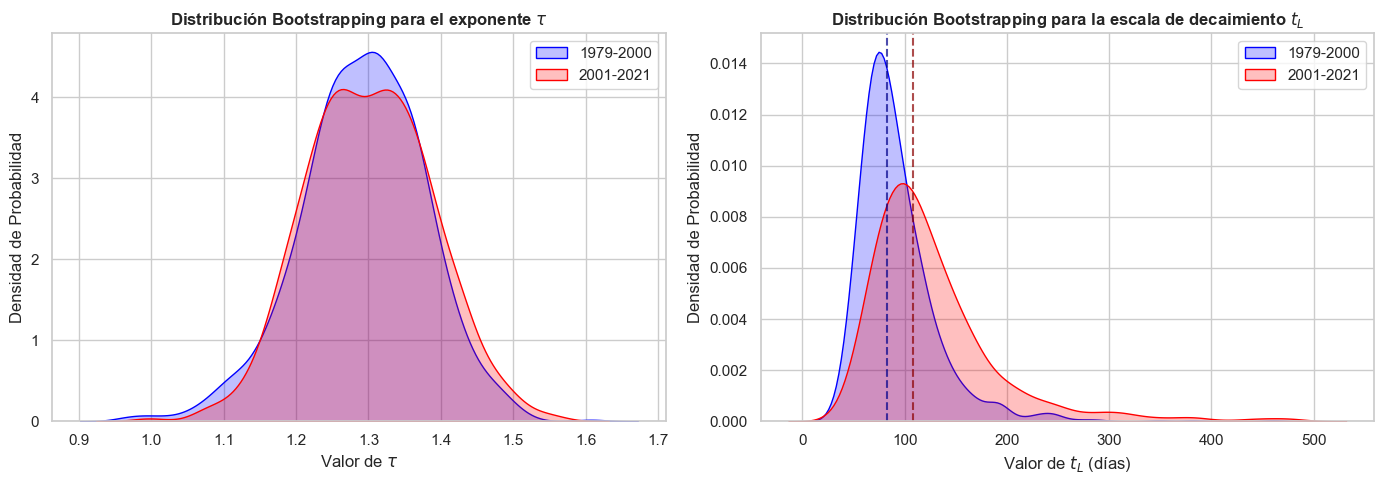

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn es genial para distribuciones

# Configurar el estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Distribución del parámetro Tau ---
sns.kdeplot(boot_tau_p1, fill=True, color="blue", label="1979-2000", ax=axes[0])
sns.kdeplot(boot_tau_p2, fill=True, color="red", label="2001-2021", ax=axes[0])
axes[0].set_title("Distribución Bootstrapping para el exponente $\\tau$", fontweight='bold')
axes[0].set_xlabel("Valor de $\\tau$")
axes[0].set_ylabel("Densidad de Probabilidad")
axes[0].legend()

# --- Gráfico 2: Distribución del parámetro tL ---
# Filtramos valores extremos (>500) solo para que el gráfico se vea bien, 
# ya que la función a veces tira valores al infinito cuando c3 es casi 0.
tL_p1_filtered = [x for x in boot_tL_p1 if x < 500]
tL_p2_filtered = [x for x in boot_tL_p2 if x < 500]

sns.kdeplot(tL_p1_filtered, fill=True, color="blue", label="1979-2000", ax=axes[1])
sns.kdeplot(tL_p2_filtered, fill=True, color="red", label="2001-2021", ax=axes[1])
axes[1].set_title("Distribución Bootstrapping para la escala de decaimiento $t_L$", fontweight='bold')
axes[1].set_xlabel("Valor de $t_L$ (días)")
axes[1].set_ylabel("Densidad de Probabilidad")
axes[1].legend()

# Mostrar líneas de los valores originales
tL_orig_p1, tL_orig_p2 = 82.6, 108.3 # Los valores de tu gráfico
axes[1].axvline(tL_orig_p1, color='darkblue', linestyle='--', alpha=0.7)
axes[1].axvline(tL_orig_p2, color='darkred', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()